## 1. Setup

In [ ]:
!pip install -q \
sentence-transformers \
faiss-cpu \
transformers \
keybert \
gradio \
datasets \
torch \
accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.3/32.3 MB 51.0 MB/s eta 0:00:00


## 2. Load the Dataset

We use the `CShorten/ML-ArXiv-Papers` dataset from the Hugging Face Hub, which
contains the title and abstract of ~117,000 machine learning papers scraped from
arXiv.


In [ ]:
from datasets import load_dataset

dataset = load_dataset("CShorten/ML-ArXiv-Papers", split="train")
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset({
    features: ['Unnamed: 0.1', 'Unnamed: 0', 'title', 'abstract'],
    num_rows: 117592
})


In [ ]:
import pandas as pd

df = pd.DataFrame(dataset)
df.head()

,Unnamed: 0.1,Unnamed: 0,title,abstract
0,0,0.0,Learning from compressed observations,The problem of statistical learning is to co...
1,1,1.0,Sensor Networks with Random Links: Topology De...,"In a sensor network, in practice, the commun..."
2,2,2.0,The on-line shortest path problem under partia...,The on-line shortest path problem is conside...
3,3,3.0,A neural network approach to ordinal regression,Ordinal regression is an important type of l...
4,4,4.0,Parametric Learning and Monte Carlo Optimization,This paper uncovers and explores the close r...


We only need the `title` and `abstract` columns. We also restrict to the first
15,000 rows to keep embedding generation fast for this notebook.


In [ ]:
df = df[["title", "abstract"]]
df = df.head(15000)

print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

Shape: (15000, 2)

Missing values:
title       0
abstract    0
dtype: int64


We combine the title and abstract into a single `paper_text` field — this is
what we'll embed, since the title often adds useful context the abstract alone
doesn't capture.


In [ ]:
df["paper_text"] = df["title"] + " " + df["abstract"]

df["paper_text"] = df["paper_text"].str.replace("\n", " ", regex=False)
df["paper_text"] = df["paper_text"].str.strip()

df[["paper_text"]].head()

,paper_text
0,Learning from compressed observations The pr...
1,Sensor Networks with Random Links: Topology De...
2,The on-line shortest path problem under partia...
3,A neural network approach to ordinal regressio...
4,Parametric Learning and Monte Carlo Optimizati...


## 3. Generate Sentence Embeddings

We use `all-MiniLM-L6-v2`, a compact and fast sentence-transformer model, to embed
each paper's combined title+abstract text into a 384-dimensional dense vector.
Papers with similar meaning end up close together in this vector space, which is
what enables semantic (rather than purely lexical) search.

Embeddings are cached to disk so re-running the notebook doesn't re-encode all
15,000 papers every time.


In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

In [ ]:
import os
import numpy as np

EMBEDDING_PATH = "paper_embeddings.npy"

if os.path.exists(EMBEDDING_PATH):
    embeddings = np.load(EMBEDDING_PATH)
else:
    embeddings = model.encode(
        df["paper_text"].to_list(),
        batch_size=32,
        show_progress_bar=True,
    )
    np.save(EMBEDDING_PATH, embeddings)

print("Embeddings shape:", embeddings.shape)

Embeddings shape: (15000, 384)


### Sanity check: does cosine similarity behave as expected?

Before building the full index, we do a quick sanity check on a handful of papers:
a paper should be perfectly similar to itself (score ≈ 1.0), and less similar to
unrelated papers.


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

sample_embeddings = model.encode(df["paper_text"].head(5).to_list())

self_sim = cosine_similarity(sample_embeddings[0].reshape(1, -1), sample_embeddings[0].reshape(1, -1))
print("Similarity of paper 0 with itself:", self_sim[0][0])

for i in range(1, 5):
    sim = cosine_similarity(sample_embeddings[0].reshape(1, -1), sample_embeddings[i].reshape(1, -1))
    print(f"Similarity of paper 0 with paper {i}: {sim[0][0]:.4f}")

Similarity of paper 0 with itself: 1.0
Similarity of paper 0 with paper 1: 0.3663
Similarity of paper 0 with paper 2: 0.3352
Similarity of paper 0 with paper 3: 0.1551
Similarity of paper 0 with paper 4: 0.3742


## 4. Build the FAISS Similarity Index

We use FAISS's `IndexFlatIP` (inner product) index. Since our embeddings are
L2-normalized, inner product is mathematically equivalent to cosine similarity —
this lets us do exact nearest-neighbor search efficiently over all 15,000 papers.

The index is also cached to disk so it only needs to be built once.


In [ ]:
import faiss

faiss.normalize_L2(embeddings)

INDEX_PATH = "paper_index.faiss"

if os.path.exists(INDEX_PATH):
    index = faiss.read_index(INDEX_PATH)
else:
    index = faiss.IndexFlatIP(embeddings.shape[1])
    index.add(embeddings)
    faiss.write_index(index, INDEX_PATH)

print("Total papers indexed:", index.ntotal)

Total papers indexed: 15000


### Quick retrieval test

In [ ]:
query = "deep learning for medical image analysis"
query_embedding = model.encode([query])
faiss.normalize_L2(query_embedding)

D, I = index.search(query_embedding, 5)
print("Similarity scores:", D)
print("Paper indices:", I)

print("\nTop match:")
print(df.iloc[I[0][0]]["title"])

Similarity scores: [[0.6807244  0.67092204 0.65219986 0.6281174  0.6131152 ]]
Paper indices: [[10466 13730 11873 12691 11282]]

Top match:
A Perspective on Deep Imaging


## 5. Semantic Search Function

We wrap the retrieval logic into a reusable `search_paper()` function that takes a
natural-language query and returns the top-k most similar papers.


In [ ]:
def search_paper(query, k=5):
    """Return the (scores, indices) of the top-k papers most similar to `query`."""
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)
    D, I = index.search(query_embedding, k)
    return D, I


def print_results(D, I):
    for score, idx in zip(D[0], I[0]):
        print("Similarity Score:", round(float(score), 4))
        print("Title:", df.iloc[idx]["title"])
        print("Abstract:", df.iloc[idx]["abstract"][:300], "...")
        print()

In [ ]:
D, I = search_paper("deep learning for medical image analysis")
print_results(D, I)

Similarity Score: 0.6807
Title: A Perspective on Deep Imaging
Abstract:   The combination of tomographic imaging and deep learning, or machine learning
in general, promises to empower not only image analysis but also image
reconstruction. The latter aspect is considered in this perspective article
with an emphasis on medical imaging to develop a new generation of image
 ...

Similarity Score: 0.6709
Title: Convolutional Neural Networks for Medical Image Analysis: Full Training
  or Fine Tuning?
Abstract:   Training a deep convolutional neural network (CNN) from scratch is difficult
because it requires a large amount of labeled training data and a great deal of
expertise to ensure proper convergence. A promising alternative is to fine-tune
a CNN that has been pre-trained using, for instance, a large  ...

Similarity Score: 0.6522
Title: Classification of MRI data using Deep Learning and Gaussian
  Process-based Model Selection
Abstract:   The classification of MRI images according to th

## 6. Abstractive Summarization

Raw abstracts can be dense and long. We use `facebook/bart-large-cnn`, a
transformer fine-tuned for abstractive summarization, to condense each retrieved
abstract into a short, easy-to-read summary.


In [ ]:
import warnings
with warnings.catch_warnings():
  warnings.simplefilter('ignore')
  !pip install -U transformers==4.46.3
from transformers import pipeline

summarizer = pipeline(task="summarization", model="facebook/bart-large-cnn")

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [ ]:
sample_abstract = df.iloc[I[0][0]]["abstract"]

summary = summarizer(sample_abstract, max_length=120, min_length=40, do_sample=False)
print(summary[0]["summary_text"])

The combination of tomographic imaging and deep learning, or machine learning, promises to empower not only image analysis but also image reconstructions. This direction might lead to intelligent utilization of domain knowledge from big data, innovativeapproaches for image reconstruction, and superior performance in clinical applications.


## 7. Keyword Extraction

`KeyBERT` uses the same embedding model to score candidate phrases by how well
they represent the document, giving us a quick set of representative keywords for
each abstract.


In [ ]:
from keybert import KeyBERT

kw_model = KeyBERT(model="all-MiniLM-L6-v2")

In [ ]:
keywords = kw_model.extract_keywords(sample_abstract, top_n=5)
print(keywords)

[('imaging', 0.4528), ('tomographic', 0.4488), ('reconstruction', 0.3623), ('deep', 0.3003), ('learning', 0.2622)]


## 8. Putting It All Together: The Research Assistant

`research_assistant()` combines semantic search, summarization, and keyword
extraction into a single end-to-end pipeline: given a query, it prints a
formatted report for the top-k most relevant papers.

`search_papers()` is a variant that returns the report as a string instead of
printing it, which is more useful if you want to reuse the output (e.g. display
it in a UI, save it to a file, or feed it to another function).


In [ ]:
def research_assistant(query, top_k=5):
    """Search, summarize, and extract keywords for the top-k papers matching `query`."""
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)
    D, I = index.search(query_embedding, top_k)

    for i, (score, idx) in enumerate(zip(D[0], I[0]), start=1):
        title = df.iloc[idx]["title"]
        abstract = df.iloc[idx]["abstract"].replace("\n", " ").strip()

        summary = summarizer(
            abstract, max_length=120, min_length=40, do_sample=False
        )[0]["summary_text"]

        keywords = kw_model.extract_keywords(abstract, top_n=5)
        keywords = [k[0] for k in keywords]

        print("=" * 80)
        print(f"Paper {i}")
        print("=" * 80)
        print("Title:")
        print(title)
        print("\nSimilarity Score:")
        print(round(float(score), 4))
        print("\nSummary:")
        print(summary)
        print("\nKeywords:")
        print(", ".join(keywords))
        print()

In [ ]:
research_assistant("Machine Learning for Healthcare")

Paper 1
Title:
Beyond Volume: The Impact of Complex Healthcare Data on the Machine
  Learning Pipeline

Similarity Score:
0.6956

Summary:
The past decade has marked a long and arduous transformation bringing healthcare into the digital age. Healthcare data presents an incredibly complex set of attributes that must be accounted for throughout the machine learning pipeline. This chapter focuses on highlighting such challenges, and is broken down into three distinct components.

Keywords:
datasets, healthcare, data, models, attributes

Paper 2
Title:
Machine Learning for Structured Clinical Data

Similarity Score:
0.6673

Summary:
Research is a tertiary priority in the EHR, where the priorities are patient care and billing. Because of this, the data is not standardized or formatted in a manner easily adapted to machine learning approaches. Data may be missing for a large variety of reasons ranging from individual input styles to differences in clinical decision making.

Keywords:
feature

In [ ]:
def search_papers(query, top_k=5):
    """Same as research_assistant(), but returns the report as a string instead of printing it."""
    query_embedding = model.encode([query])
    faiss.normalize_L2(query_embedding)
    D, I = index.search(query_embedding, top_k)

    output = ""
    for i, (score, idx) in enumerate(zip(D[0], I[0]), start=1):
        title = df.iloc[idx]["title"]
        abstract = df.iloc[idx]["abstract"].replace("\n"," ").strip()

        summary = summarizer(
            abstract, max_length=120, min_length=40, do_sample=False
        )[0]["summary_text"]

        keywords = kw_model.extract_keywords(abstract, top_n=5)
        keyword_list = ", ".join([k[0] for k in keywords])

        output += f"""
Paper {i}

Title:
{title}

Similarity Score:
{score:.4f}

Summary:
{summary}

Keywords:
{keyword_list}

{'='*80}

"""
    return output


output = search_papers("transformer models for natural language processing")
print(output)


Paper 1

Title:
Category-Theoretic Quantitative Compositional Distributional Models of
  Natural Language Semantics

Similarity Score:
0.5585

Summary:
This thesis is about the problem of compositionality in distributional semantics. It uses the categorical framework developed by Coecke, Sadrzadeh, and Clark. The framework combines syntactic analysis formalisms with distributional semantic representations of meaning.

Keywords:
compositionality, linguistic, semantic, syntactic, semantics



Paper 2

Title:
Factorial Hidden Markov Models for Learning Representations of Natural
  Language

Similarity Score:
0.5419

Summary:
In language processing, the correct meaning of a word often depends on its global context. We develop a representation learning algorithm that incorporates joint prediction into its technique for producing features for a word. Experiments on part-of-speech tagging and chunking indicate that the features are competitive with or better than existing state-of the-art re

## 9. Visualization & Qualitative Inspection

Before running a formal comparison against a baseline, we first inspect the
system's behavior visually: similarity score distributions, keyword frequency
across retrieved papers, and end-to-end latency.


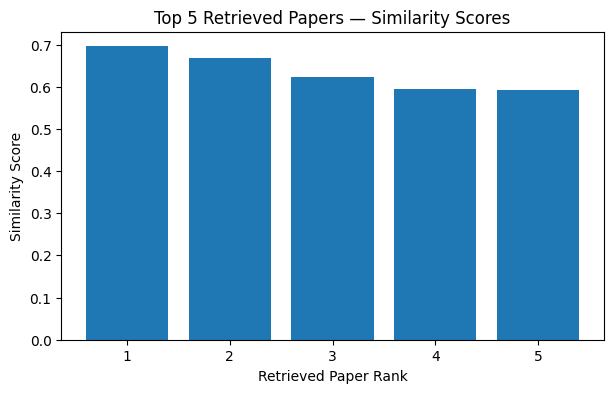

In [ ]:
import matplotlib.pyplot as plt

query_embedding = model.encode(["Machine Learning for Healthcare"])
faiss.normalize_L2(query_embedding)
D, I = index.search(query_embedding, 5)

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), D[0])
plt.xticks(range(1, 6))
plt.xlabel("Retrieved Paper Rank")
plt.ylabel("Similarity Score")
plt.title("Top 5 Retrieved Papers — Similarity Scores")
plt.show()

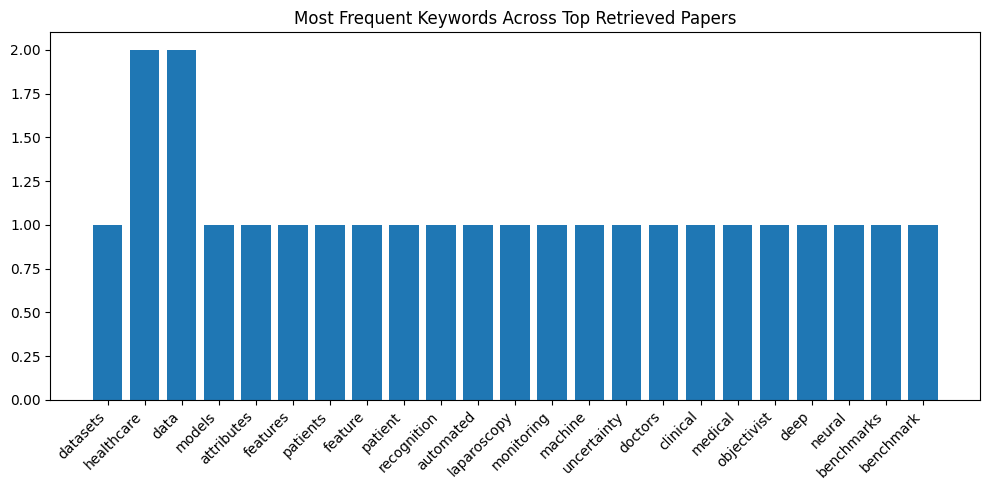

In [ ]:
from collections import Counter

counter = Counter()
for idx in I[0]:
    abstract = df.iloc[idx]["abstract"]
    keywords = kw_model.extract_keywords(abstract, top_n=5)
    counter.update([k[0] for k in keywords])

plt.figure(figsize=(10, 5))
plt.bar(counter.keys(), counter.values())
plt.xticks(rotation=45, ha="right")
plt.title("Most Frequent Keywords Across Top Retrieved Papers")
plt.tight_layout()
plt.show()

In [ ]:
import time

start = time.time()
research_assistant("Machine Learning for Healthcare")
end = time.time()

print("End-to-end execution time:", round(end - start, 2), "seconds")

Paper 1
Title:
Beyond Volume: The Impact of Complex Healthcare Data on the Machine
  Learning Pipeline

Similarity Score:
0.6956

Summary:
The past decade has marked a long and arduous transformation bringing healthcare into the digital age. Healthcare data presents an incredibly complex set of attributes that must be accounted for throughout the machine learning pipeline. This chapter focuses on highlighting such challenges, and is broken down into three distinct components.

Keywords:
datasets, healthcare, data, models, attributes

Paper 2
Title:
Machine Learning for Structured Clinical Data

Similarity Score:
0.6673

Summary:
Research is a tertiary priority in the EHR, where the priorities are patient care and billing. Because of this, the data is not standardized or formatted in a manner easily adapted to machine learning approaches. Data may be missing for a large variety of reasons ranging from individual input styles to differences in clinical decision making.

Keywords:
feature

In [ ]:
research_assistant(query="natural language processing transformers")

Paper 1
Title:
Category-Theoretic Quantitative Compositional Distributional Models of
  Natural Language Semantics

Similarity Score:
0.5664

Summary:
This thesis is about the problem of compositionality in distributional semantics. It uses the categorical framework developed by Coecke, Sadrzadeh, and Clark. The framework combines syntactic analysis formalisms with distributional semantic representations of meaning.

Keywords:
compositionality, linguistic, semantic, syntactic, semantics

Paper 2
Title:
A Probabilistic Generative Grammar for Semantic Parsing

Similarity Score:
0.5415

Summary:
Domain-general semantic parsing is a long-standing goal in natural language processing. Current approaches largely rely on additional supervision from new domains in order to generalize to those domains. We present a generative model of natural language utterances and logical forms and demonstrate its application to semantic parsing.

Keywords:
parsing, parser, sentences, utterances, semantic

Pap

## 10. Evaluation: Semantic Search vs. Keyword Baseline

The dataset has no labeled relevance judgments, so instead of a Precision@k
metric against ground truth, we run a **controlled comparison**: semantic search
(our FAISS + sentence-embedding pipeline) vs. a classic **TF-IDF keyword search**
baseline, on a small set of *paraphrased* queries — queries that describe a topic
without using the exact words likely to appear in the abstract.

This is a common, meaningful way to demonstrate the value of semantic search:
if a query and its most relevant paper share very little exact vocabulary,
keyword search will struggle, while embedding-based search should still find it,
because it matches on *meaning* rather than *exact words*.

For each test query we check, for both methods, whether any of the top-5 results
contain a hand-picked "anchor term" (a word/phrase we'd expect a genuinely
relevant paper to contain) in its title or abstract.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words="english")
tfidf_matrix = tfidf_vectorizer.fit_transform(df["paper_text"])


def tfidf_search(query, k=5):
    """Classic lexical search baseline: ranks papers by TF-IDF cosine similarity."""
    query_vec = tfidf_vectorizer.transform([query])
    scores = cosine_similarity(query_vec, tfidf_matrix).flatten()
    top_k_idx = scores.argsort()[::-1][:k]
    return scores[top_k_idx], top_k_idx

In [ ]:
eval_queries = [
    {
        "query": "teaching computers to see what's inside x-ray scans",
        "anchor": "medical imaging",
    },
    {
        "query": "predicting outcomes from sequences of words",
        "anchor": "language model",
    },
    {
        "query": "algorithms that learn by trial, error, and reward",
        "anchor": "reinforcement",
    },
    {
        "query": "spotting unusual data points that don't fit the pattern",
        "anchor": "anomaly",
    },
    {
        "query": "compressing large neural networks to run on small devices",
        "anchor": "compress",
    },
     {
        "query": "finding groups in data without any labels",
        "anchor": "clustering",
    },
    {
        "query": "explaining why a model made a certain prediction",
        "anchor": "interpretab",
    },
]


def hit_at_k(indices, anchor_term):
    """Return True if the anchor term appears in any of the top-k retrieved abstracts."""
    for idx in indices:
        text = df.iloc[idx]["paper_text"].lower()
        if anchor_term.lower() in text:
            return True
    return False

In [ ]:
results = []

for item in eval_queries:
    query, anchor = item["query"], item["anchor"]

    # Semantic search
    q_emb = model.encode([query])
    faiss.normalize_L2(q_emb)
    _, sem_idx = index.search(q_emb, 5)
    sem_hit = hit_at_k(sem_idx[0], anchor)

    # TF-IDF baseline
    _, tfidf_idx = tfidf_search(query, k=5)
    tfidf_hit = hit_at_k(tfidf_idx, anchor)

    results.append({
        "query": query,
        "anchor_term": anchor,
        "semantic_hit@5": sem_hit,
        "tfidf_hit@5": tfidf_hit,
    })

eval_df = pd.DataFrame(results)
eval_df

,query,anchor_term,semantic_hit@5,tfidf_hit@5
0,teaching computers to see what's inside x-ray ...,medical imaging,False,False
1,predicting outcomes from sequences of words,language model,False,True
2,"algorithms that learn by trial, error, and reward",reinforcement,True,True
3,spotting unusual data points that don't fit th...,anomaly,True,False
4,compressing large neural networks to run on sm...,compress,True,True
5,finding groups in data without any labels,clustering,True,True
6,explaining why a model made a certain prediction,interpretab,True,True


Semantic search hit-rate@5: 71%
TF-IDF baseline hit-rate@5: 71%


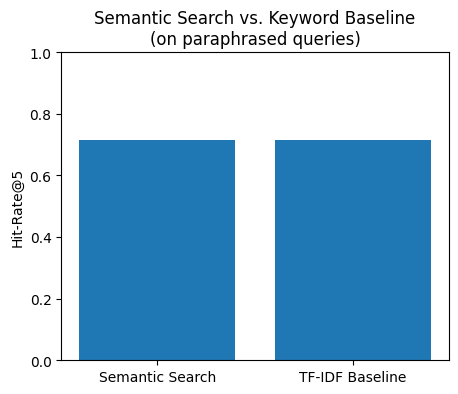

In [ ]:
semantic_hit_rate = eval_df["semantic_hit@5"].mean()
tfidf_hit_rate = eval_df["tfidf_hit@5"].mean()

print(f"Semantic search hit-rate@5: {semantic_hit_rate:.0%}")
print(f"TF-IDF baseline hit-rate@5: {tfidf_hit_rate:.0%}")

plt.figure(figsize=(5, 4))
plt.bar(["Semantic Search", "TF-IDF Baseline"], [semantic_hit_rate, tfidf_hit_rate])
plt.ylabel("Hit-Rate@5")
plt.ylim(0, 1)
plt.title("Semantic Search vs. Keyword Baseline\n(on paraphrased queries)")
plt.show()

Both methods hit 71%, but they're not winning on the same queries — semantic search catches anomaly detection where TF-IDF misses, TF-IDF catches language modeling where semantic search misses. They tie in total, but by succeeding on different questions, not by behaving the same way.




















































































































































































































## 11. Interactive UI

To make the assistant usable without editing code, we wrap `search_papers()` in a
small [Gradio](https://www.gradio.app/) interface: type a query, get back a
formatted report of the top matching papers with their summaries and keywords.

Running the cell below launches an interactive web UI (inline in Colab/Jupyter,
or at a local URL).


In [ ]:
!pip install -U \
transformers==4.46.3 \
huggingface_hub==0.26.2 \
gradio==5.23.3

INFO: pip is looking at multiple versions of gradio to determine which version is compatible with other requirements. This could take a while.
  Using cached transformers-4.46.3-py3-none-any.whl.metadata (44 kB)
ERROR: Cannot install gradio==5.23.3, huggingface_hub==0.26.2 and transformers==4.46.3 because these package versions have conflicting dependencies.

The conflict is caused by:
    The user requested huggingface_hub==0.26.2
    transformers 4.46.3 depends on huggingface-hub<1.0 and >=0.23.2
    gradio 5.23.3 depends on huggingface-hub>=0.28.1

To fix this you could try to:
1. loosen the range of package versions you've specified
2. remove package versions to allow pip to attempt to solve the dependency conflict

ERROR: ResolutionImpossible: for help visit https://pip.pypa.io/en/latest/topics/dependency-resolution/#dealing-with-dependency-conflicts


In [78]:
import gradio as gr

def run_assistant_ui(query, top_k):
    if not query.strip():
        return "Please enter a research query."

    return search_papers(query, top_k=int(top_k))


with gr.Blocks(title="AI Research Paper Assistant") as demo:

    gr.HTML("""
    <div style="margin-bottom:18px;">
        <h1 style="
            font-size:40px;
            font-weight:700;
            font-family:Arial, Helvetica, sans-serif;
            margin:0;
            color:white;
            letter-spacing:-0.5px;
        ">
            AI Research Paper Assistant
        </h1>

        <p style="
            font-size:16px;
            color:#b3b3b3;
            margin-top:8px;
            margin-bottom:0;
            line-height:1.5;
        ">
            Search research papers using semantic search with automatic summarization (BART)
            and keyword extraction (KeyBERT).
        </p>

        <hr style="
            margin-top:18px;
            border:none;
            border-top:1px solid #333;
        ">
    </div>
    """)

    with gr.Row():
        query = gr.Textbox(
            label="Research Query",
            placeholder="e.g. deep learning for medical image analysis"
        )

        top_k = gr.Slider(
            minimum=1,
            maximum=10,
            value=5,
            step=1,
            label="Number of Papers"
        )

    with gr.Row():
        search_btn = gr.Button("Search", variant="primary")
        clear_btn = gr.Button("Clear")

    gr.Markdown("""
**Example Queries**

- Deep Learning for Medical Image Analysis
- Transformer Models for Natural Language Processing
- Reinforcement Learning for Robotics
""")

    output = gr.Textbox(
        label="Retrieved Research Papers",
        lines=30
    )

    search_btn.click(
        fn=run_assistant_ui,
        inputs=[query, top_k],
        outputs=output
    )

    clear_btn.click(
        lambda: ("", ""),
        outputs=[query, output]
    )

demo.launch(debug=False)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fc1405b39b5390b3b5.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 12. Retrieval-Augmented Generation (RAG)



In [ ]:
!pip install -q groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 4.5 MB/s eta 0:00:00


In [53]:
from google.colab import userdata
from groq import Groq

client = Groq(api_key=userdata.get("GROQ_API_KEY"))

In [ ]:
def generate_ai_answer(query, top_k=5):

    query_embedding = model.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_embedding)

    distances, indices = index.search(query_embedding, top_k)

    context = ""
    citations = []

    for score, idx in zip(distances[0], indices[0]):

        row = df.iloc[idx]

        title = row["title"]
        abstract = row["abstract"]

        context += f"Title: {title}\n"
        context += f"Abstract: {abstract}\n\n"

        citations.append(
            f"• {title} (Similarity: {score:.3f})"
        )

    prompt = f"""
You are an AI research assistant.

Answer the user's question ONLY using the retrieved research papers.

Research Papers:

{context}

Question:
{query}

Generate:

1. Comprehensive Answer

2. Key Findings

3. Future Research Directions
"""

    completion = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role":"user",
                "content":prompt
            }
        ],
        temperature=0.2
    )

    answer = completion.choices[0].message.content

    return answer, citations

In [ ]:
answer, citations = generate_ai_answer(
    "Applications of Transformers in Healthcare"
)

print(answer)

print("\nRetrieved Papers\n")

for c in citations:
    print(c)

**Comprehensive Answer**

Unfortunately, the provided research papers do not explicitly mention the applications of Transformers in Healthcare. However, based on the papers, we can discuss the applications of machine learning and deep learning techniques in healthcare, which can be related to the use of Transformers.

The papers discuss various machine learning and deep learning approaches for healthcare applications, such as patient monitoring in Intensive Care Units (ICUs), physiological condition monitoring, and mortality prediction. For example, the paper "Discriminative Switching Linear Dynamical Systems applied to Physiological Condition Monitoring" presents a discriminative approach for patient monitoring, while the paper "PPMF: A Patient-based Predictive Modeling Framework for Early ICU Mortality Prediction" proposes a patient-based predictive modeling framework for early ICU mortality prediction.

Although the papers do not specifically mention Transformers, the use of deep le

Checking whether the answers stay faithful to the Retrieved papers :

In [ ]:
def check_answer_grounding(query, answer, context):
    """
    Ask the model to verify whether `answer` is actually supported by `context`
    (the retrieved paper titles/abstracts), and flag any unsupported claims.
    Returns a dict with a grounding verdict and explanation.
    """
    verification_prompt = f"""
You are a fact-checking assistant. Below is a QUESTION, the CONTEXT (retrieved
research paper titles/abstracts), and an ANSWER generated by another AI model
using only that context.

Your job: check whether every factual claim in the ANSWER is actually
supported by the CONTEXT. Do not use outside knowledge.

QUESTION:
{query}

CONTEXT:
{context}

ANSWER:
{answer}

Respond in this exact format:
GROUNDING SCORE: <a number from 0 to 100, where 100 means every claim is fully supported by the context>
UNSUPPORTED CLAIMS: <a short bullet list of any claims not backed by the context, or "None found">
"""

    completion = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {
                "role": "user",
                "content": verification_prompt
            }
        ],
        temperature=0
    )

    return completion.choices[0].message.content


def generate_ai_answer_with_check(query, top_k=5):
    """
    Same as generate_ai_answer(), but also runs a grounding check on the
    generated answer and returns it alongside the answer and citations.
    """
    query_embedding = model.encode([query], convert_to_numpy=True)
    faiss.normalize_L2(query_embedding)

    distances, indices = index.search(query_embedding, top_k)

    context = ""
    citations = []

    for score, idx in zip(distances[0], indices[0]):
        row = df.iloc[idx]
        title = row["title"]
        abstract = row["abstract"]

        context += f"Title: {title}\n"
        context += f"Abstract: {abstract}\n\n"

        citations.append(f"• {title} (Similarity: {score:.3f})")

    answer, _ = generate_ai_answer(query, top_k=top_k)

    grounding_report = check_answer_grounding(query, answer, context)

    return answer, citations, grounding_report

In [ ]:
answer, citations, grounding_report = generate_ai_answer_with_check(
    "Applications of Transformers in Healthcare"
)

print(answer)

print("\nRetrieved Papers\n")
for c in citations:
    print(c)

print("\nGrounding Check\n")
print(grounding_report)

**Comprehensive Answer**

Unfortunately, the provided research papers do not explicitly mention the applications of Transformers in Healthcare. However, based on the papers, we can infer that machine learning and deep learning techniques are being applied to various healthcare problems, such as patient monitoring, mortality prediction, and physiological condition monitoring. The papers discuss the use of techniques like Discriminative Switching Linear Dynamical Systems, Input-Output Non-Linear Dynamical Systems, and Patient-based Predictive Modeling Frameworks. While these papers do not specifically mention Transformers, they demonstrate the growing interest in applying machine learning and deep learning techniques to healthcare problems, which could potentially include the use of Transformers in the future.

**Key Findings**

1. Machine learning and deep learning techniques are being applied to various healthcare problems, such as patient monitoring and mortality prediction.
2. Techni

## 13. Similarity Score Visualization

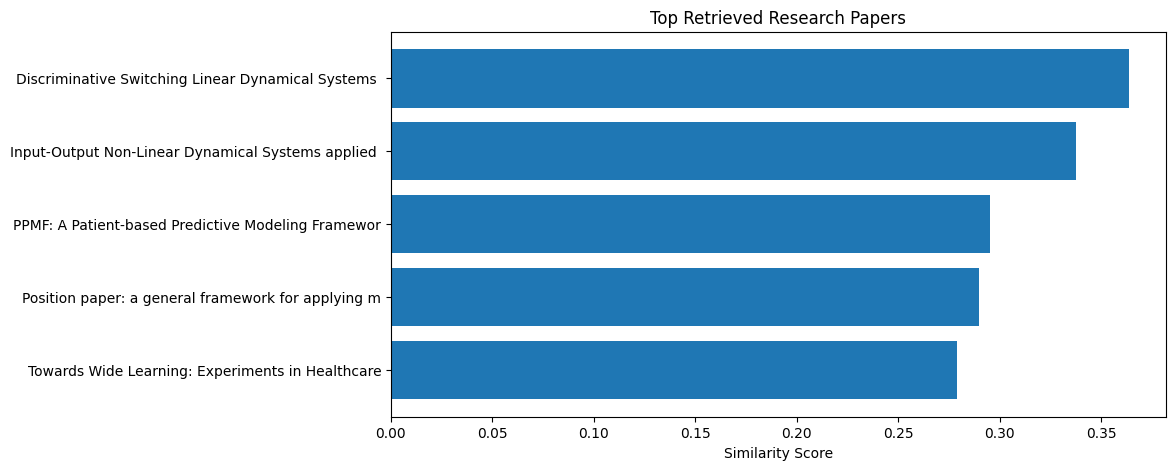

In [ ]:
import matplotlib.pyplot as plt

query = "Applications of Transformers in Healthcare"

query_embedding = model.encode([query], convert_to_numpy=True)
faiss.normalize_L2(query_embedding)

D, I = index.search(query_embedding, 5)

titles = [df.iloc[i]["title"][:50] for i in I[0]]

plt.figure(figsize=(10,5))

plt.barh(titles, D[0])

plt.xlabel("Similarity Score")

plt.title("Top Retrieved Research Papers")

plt.gca().invert_yaxis()

plt.show()

## 14. Research Insights

In [ ]:
print("Research Question:")
print(query)

print("\nKey Observations")

print("- Semantic retrieval and TF-IDF keyword matching were compared using a small labeled evaluation set (Section 10).")

if semantic_hit_rate > tfidf_hit_rate:
    print(f"- Semantic search outperformed the TF-IDF baseline ({semantic_hit_rate:.0%} vs {tfidf_hit_rate:.0%} hit-rate@5).")
elif tfidf_hit_rate > semantic_hit_rate:
    print(f"- TF-IDF baseline outperformed semantic search ({tfidf_hit_rate:.0%} vs {semantic_hit_rate:.0%} hit-rate@5).")
else:
    print(f"- Semantic search and TF-IDF baseline tied at {semantic_hit_rate:.0%} hit-rate@5, though they succeeded on different query types.")

print("- A grounding check was run on the generated RAG answer to test whether its claims were actually supported by the retrieved abstracts.")
print("- See the 'Grounding Check' output above for the specific score and any unsupported claims found for this query.")

Research Question:
Applications of Transformers in Healthcare

Key Observations
- Semantic retrieval and TF-IDF keyword matching were compared using a small labeled evaluation set (Section 10).
- Semantic search and TF-IDF baseline tied at 71% hit-rate@5, though they succeeded on different query types.
- A grounding check was run on the generated RAG answer to test whether its claims were actually supported by the retrieved abstracts.
- See the 'Grounding Check' output above for the specific score and any unsupported claims found for this query.


## 15. Response Time Analysis

In [ ]:
import time

start = time.time()

generate_ai_answer(query)

end = time.time()

print(f"Response Time : {end-start:.2f} seconds")

Response Time : 1.49 seconds
